# Chatbot Movie Recommendation System

## Introduction:
Picture this scenario: You're in the mood to watch a movie, but you've exhausted your list of preferred films. In such a situation, the recommendation system will analyze your desired movie criteria against a database of movie descriptions and propose the top five movies that closely align with your preferences.
### Purpose:
The primary objective is to enable the machine to intelligently suggest movies to users based on their preferences. This involves creating a model capable of processing and comprehending movie data with the ultimate aim of providing users with an entertaining experience.
### Major Problem:
•Addressed a significant NLP challenge involving the comprehension of human text by machines.
•Explored the interpretation of movie data and the importance of various features, addressing a similar issue.
### Types of Recommendation System:
**•Contextual Type:**: Utilizing diverse inputs, including keywords, enhances the intelligence of recommendations. This approach filters and ranks suggestions based on a nuanced understanding, ensuring relevance and a comprehensive grasp of user preferences.

#  Dataset:

#### Kaggle:
###### English Movies Data:. Contains information on 45,000 movies featured in the Full MovieLens dataset. Features include posters, backdrops, budget, revenue, release dates, languages, production countries and companies.

## Strategy:
The steps in this procedure are as follows:
###### 1.) Loading the data set.
###### 2.) Pre-processing the data (including tasks such as removing stop words and stemming).
###### 3.)Selecting features.
###### 4.) Constructing the recommendation system.
###### Testing the results of the model.
###### Constructing the chatbot.
###### Providing movie recommendations.


In [4]:
!pip install flask_cors
from flask import Flask, jsonify, render_template, request
from flask_cors import CORS, cross_origin
import pandas as pd
from ast import literal_eval
import numpy as np
from tqdm.notebook import tqdm
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import boto3
import pathlib
from botocore.config import Config
import seaborn as sns
from google.colab import drive

In [69]:
import anvil.server
uplink_key='server_ECZCUOI7P5OWQ3S74GLE6GMS-BOD7XEU5XKPHCJIJ'
anvil.server.connect(uplink_key)

Disconnecting from previous connection first...
Connecting to wss://anvil.works/uplink
Anvil websocket closed (code 1000, reason=b'')
Anvil websocket open
Connected to "Published" as SERVER


In [3]:
!pip install boto3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 15.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 7.8 MB/s eta 0:00:00


In [5]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
#Importing the relevant datasets from the mounted Google Drive (change the code below if the data is hosted elsewhere)
metadata = pd.read_csv('/content/gdrive/My Drive/movie_data/movies_metadata.csv')
credits = pd.read_csv('/content/gdrive/My Drive/movie_data/credits.csv')

In [7]:
list(metadata)

['adult',
 'belongs_to_collection',
 'budget',
 'genres',
 'homepage',
 'id',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'video',
 'vote_average',
 'vote_count']

In [8]:
row = []
for i,j in enumerate(metadata['id']):
    try:
        c = int(j)
    except:
        row.append(i)

In [9]:
metadata.drop(row,inplace=True)
metadata.reset_index(drop=True,inplace=True)

In [10]:
credits['id'] = credits['id'].astype('int')
metadata['id'] = metadata['id'].astype('int')

In [11]:
metadata = metadata.merge(credits, on='id')

In [12]:
metadata.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='object')

In [13]:
#Print the important features of metadata
# Fill NaN values with 0
metadata['popularity'].fillna(0, inplace=True)

# Convert the 'popularity' column to float
metadata['popularity'] = metadata['popularity'].astype(float)

# Convert the 'popularity' column to int
metadata['popularity'] = metadata['popularity'].astype(int)

# Display the head of the DataFrame
metadata[['title', 'cast', 'vote_average', 'vote_count', 'popularity', 'tagline', 'genres']].head()

,title,cast,vote_average,vote_count,popularity,tagline,genres
0,Toy Story,"[{'cast_id': 14, 'character': 'Woody (voice)',...",7.7,5415.0,21,NaN,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Jumanji,"[{'cast_id': 1, 'character': 'Alan Parrish', '...",6.9,2413.0,17,Roll the dice and unleash the excitement!,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Grumpier Old Men,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...",6.5,92.0,11,Still Yelling. Still Fighting. Still Ready for...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,Waiting to Exhale,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...",6.1,34.0,3,Friends are the people who let you be yourself...,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,Father of the Bride Part II,"[{'cast_id': 1, 'character': 'George Banks', '...",5.7,173.0,8,Just When His World Is Back To Normal... He's ...,"[{'id': 35, 'name': 'Comedy'}]"


In [14]:
metadata['genres']

0        [{'id': 16, 'name': 'Animation'}, {'id': 35, '...
1        [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...
2        [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...
3        [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...
4                           [{'id': 35, 'name': 'Comedy'}]
                               ...                        
45533    [{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...
45534                        [{'id': 18, 'name': 'Drama'}]
45535    [{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...
45536                                                   []
45537                                                   []
Name: genres, Length: 45538, dtype: object

In [15]:
metadata

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45533,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0,"[{'cast_id': 0, 'character': '', 'credit_id': ...","[{'credit_id': '5894a97d925141426c00818c', 'de..."
45534,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0,"[{'cast_id': 1002, 'character': 'Sister Angela...","[{'credit_id': '52fe4af1c3a36847f81e9b15', 'de..."
45535,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0,"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","[{'credit_id': '52fe4776c3a368484e0c8387', 'de..."
45536,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0,"[{'cast_id': 2, 'character': '', 'credit_id': ...","[{'credit_id': '533bccebc3a36844cf0011a7', 'de..."


In [16]:
data_types = metadata.dtypes
print(data_types)

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                         int64
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                 int64
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
cast                      object
crew                      object
dtype: object


In [17]:
#raises an exception if the input isn't a valid Python datatype, so the code won't be executed if it's not.
#Parse the stringified features into their corresponding python objects

from ast import literal_eval

# features = ['cast', 'vote_average','vote_count' ,'popularity','tagline','genres']
features = ['cast', 'crew', 'genres']
for feature in features:
    metadata[feature] = metadata[feature].apply(literal_eval)

In [18]:
def f(x):
    d = []
    for i in x:
        d.append(i['name'])
    return d

In [19]:
metadata['genres'] = metadata['genres'].apply(lambda x:f(x))

In [20]:
metadata['cast'] = metadata['cast'].apply(lambda x:f(x))

In [21]:
data_types = metadata.dtypes
print(data_types)

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                         int64
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                 int64
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
cast                      object
crew                      object
dtype: object


In [22]:
#This function makes use of the property of the cosine similarity funciton that
#the order and types of inputs don't matter, what matters is the similarity
#between different soups of words
def create_soup(x):
    return ' '.join(x['cast']) + ' ' + ' '.join(x['genres'])

metadata['soup'] = metadata.apply(create_soup, axis=1)

In [70]:
#Getting the user's input for genre, actors and directors of their liking.
def get_genres():
    genres = input("What Movie Genre are you interested in ? [Type 'skip' to skip this question] ")
    genres = " ".join(["".join(n.split()) for n in genres.lower().split(',')])
    return genres

def get_actors():
    actors = input("Who are some actors within the genre that you love ? [Type 'skip' to skip this question] ")
    actors = " ".join(["".join(n.split()) for n in actors.lower().split(',')])
    return actors

def get_language():
    original_language = input("What is the spoken language?[Type 'skip' to skip this question] ")
    original_language = " ".join(["".join(n.split()) for n in original_language.lower().split(',')])
    return original_language

def get_overview():
    overview = input("What are some of the keywords that describe the movie you want to watch, like elements of the plot, whether or not it is about friendship, etc? (if multiple, please separate them with a comma)? [Type 'skip' to skip this question] ")
    overview = " ".join(["".join(n.split()) for n in overview.lower().split(',')])
    return overview

def get_popularity():
    vote_average = input("What are sholud be the popularity of the movie you want to watch? [Type 'skip' to skip this question] ")
    vote_average = " ".join(["".join(n) for n in vote_average])
    return vote_average
@anvil.server.callable
def get_searchTerms():
    searchTerms = []
    genres = get_genres()
    if genres and genres != 'skip':
        searchTerms.append(genres.title())
    else:
        searchTerms.append(None)

    actors = get_actors()
    if actors and actors != 'skip':
        searchTerms.append(actors.title())
    else:
        searchTerms.append(None)

    popularity = get_popularity()
    if popularity and popularity != 'skip':
        searchTerms.append(popularity)
    else:
        searchTerms.append(None)

    overview = get_overview()
    if overview and overview != 'skip':
        searchTerms.append(overview)
    else:
        searchTerms.append(None)

    original_language = get_language()
    if original_language and original_language != 'skip':
        searchTerms.append(original_language)
    else:
        searchTerms.append(None)


    return searchTerms

In [24]:
# metadata = metadata.iloc[0:20000,:] # only using 20k movies

In [25]:
metadata = metadata[['title','genres','original_language','cast','release_date', 'vote_average' ,'soup','overview','popularity']]

In [26]:
metadata.dropna(inplace=True)

In [27]:
metadata['Year'] = metadata['release_date'].apply(lambda x:x.split('-')[0])

In [28]:
metadata.drop('release_date',axis=1,inplace=True)

In [29]:
data_full=metadata

In [30]:
data_full.columns

Index(['title', 'genres', 'original_language', 'cast', 'vote_average', 'soup',
       'overview', 'popularity', 'Year'],
      dtype='object')

# EDA

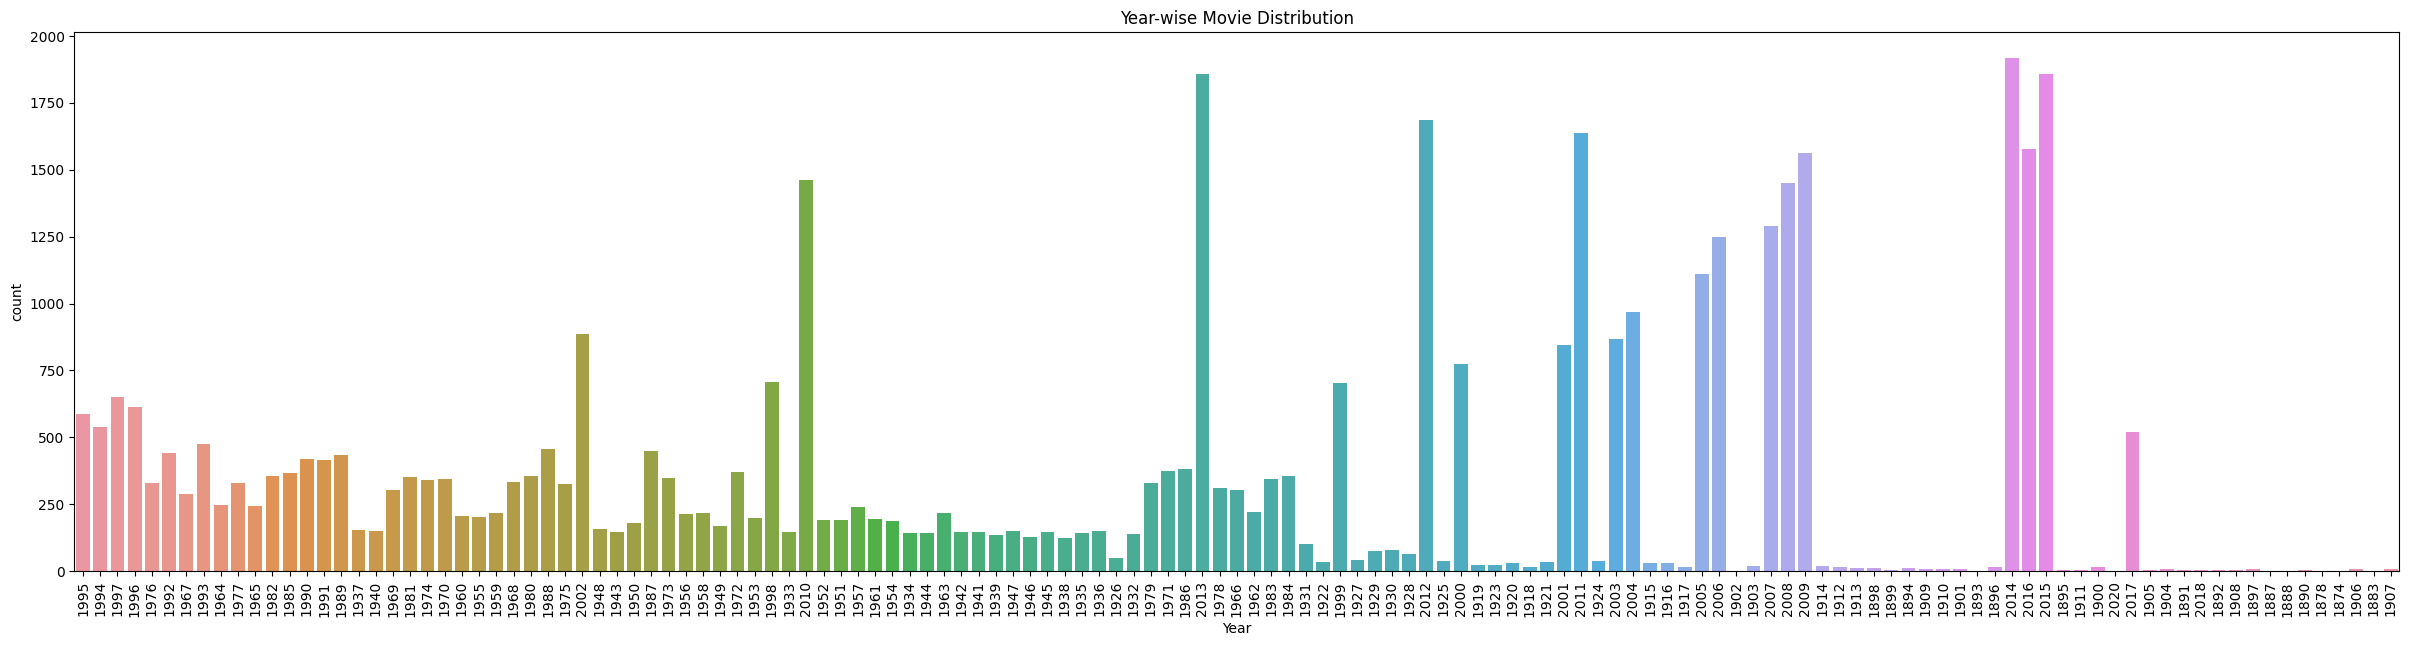

In [31]:
plt.figure(figsize=(30, 7))
plt.title('Year-wise Movie Distribution')
sns.countplot(x='Year', data=data_full)
plt.xticks(rotation=90)
plt.show()

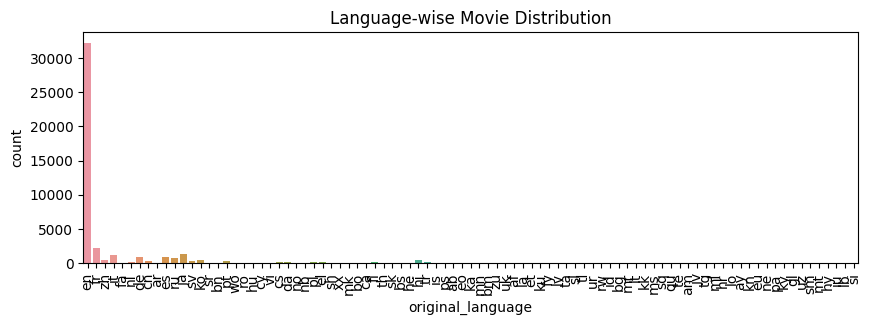

In [32]:
plt.figure(figsize=(10, 3))
plt.title('Language-wise Movie Distribution')
sns.countplot(x='original_language', data=data_full)
plt.xticks(rotation=90)
plt.show()

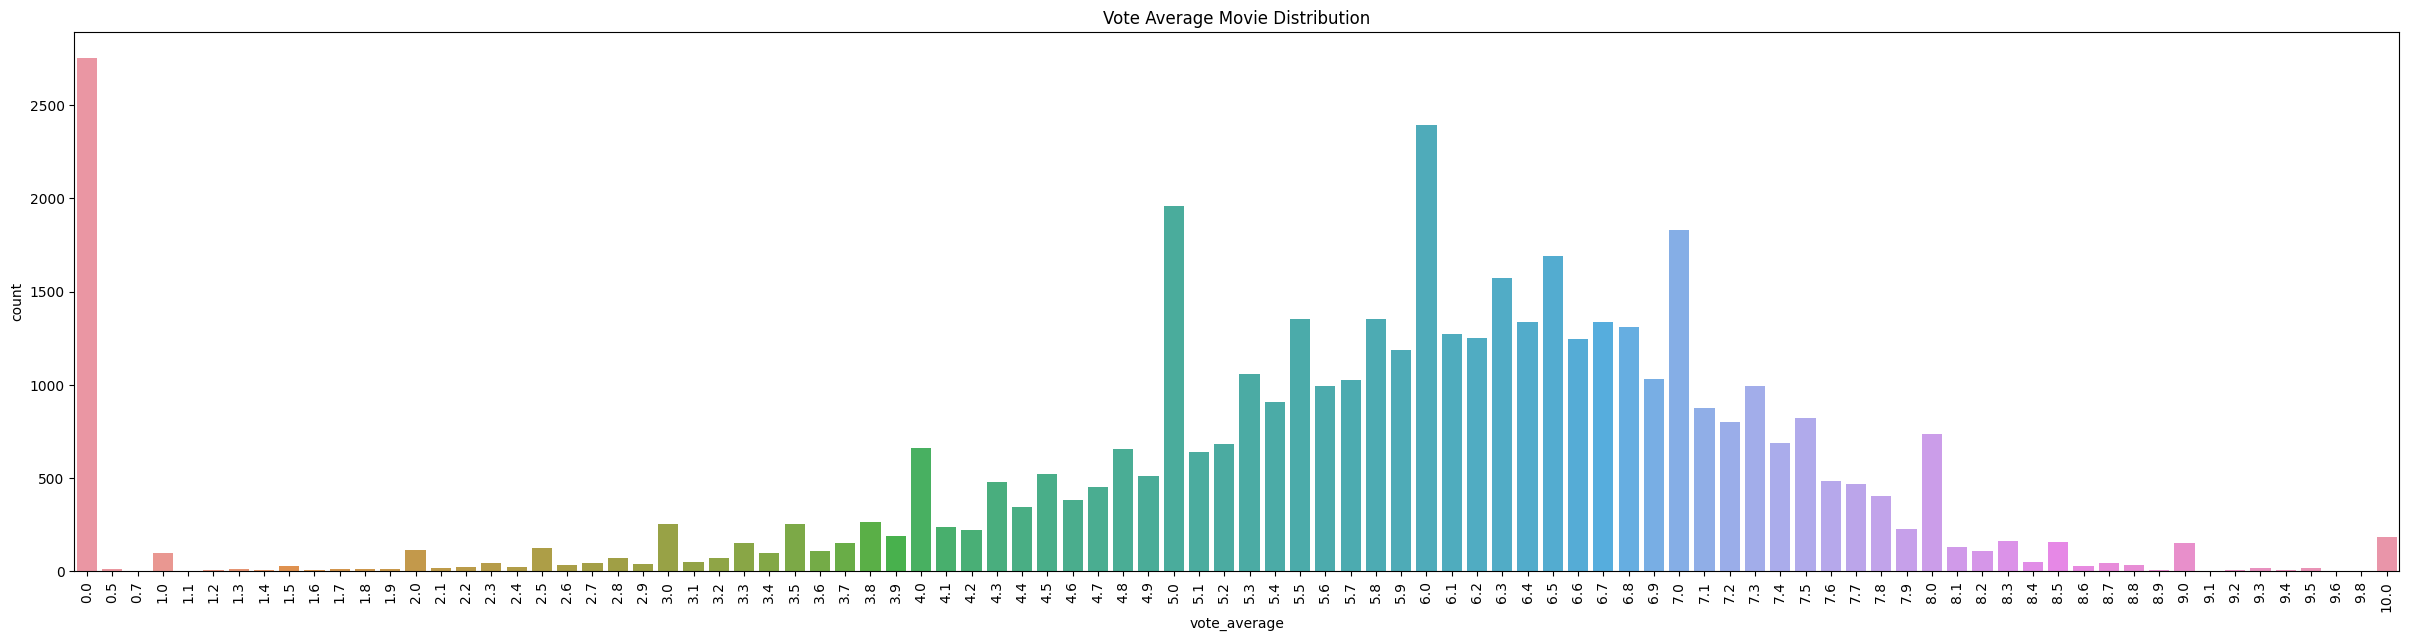

In [33]:
plt.figure(figsize=(30, 7))
plt.title('Vote Average Movie Distribution')
sns.countplot(x='vote_average', data=data_full)
plt.xticks(rotation=90)
plt.show()

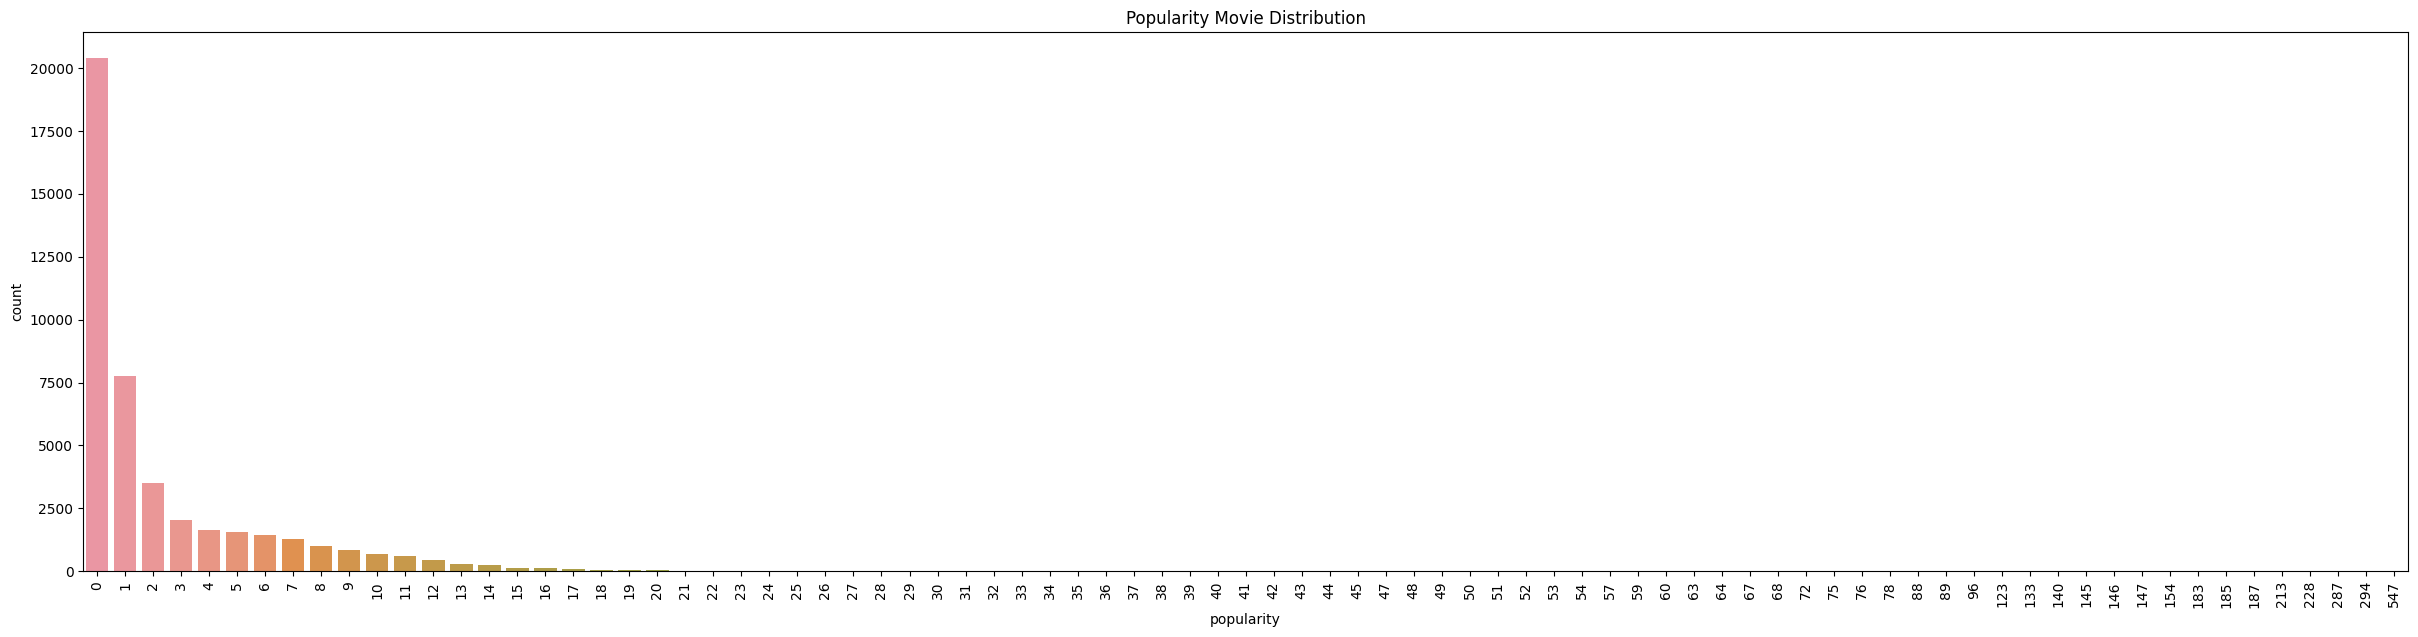

In [34]:
plt.figure(figsize=(30, 7))
plt.title('Popularity Movie Distribution')
sns.countplot(x='popularity', data=data_full)
plt.xticks(rotation=90)
plt.show()

In [35]:
category = []
from tqdm.notebook import tqdm
for cat in tqdm(data_full[data_full['original_language'].isin(['en'])]['genres']):
    category = category + cat

  0%|          | 0/32181 [00:00<?, ?it/s]

In [36]:
category

['Animation',
 'Comedy',
 'Family',
 'Adventure',
 'Fantasy',
 'Family',
 'Romance',
 'Comedy',
 'Comedy',
 'Drama',
 'Romance',
 'Comedy',
 'Action',
 'Crime',
 'Drama',
 'Thriller',
 'Comedy',
 'Romance',
 'Action',
 'Adventure',
 'Drama',
 'Family',
 'Action',
 'Adventure',
 'Thriller',
 'Adventure',
 'Action',
 'Thriller',
 'Comedy',
 'Drama',
 'Romance',
 'Comedy',
 'Horror',
 'Family',
 'Animation',
 'Adventure',
 'History',
 'Drama',
 'Action',
 'Adventure',
 'Drama',
 'Crime',
 'Drama',
 'Romance',
 'Crime',
 'Comedy',
 'Crime',
 'Comedy',
 'Adventure',
 'Action',
 'Comedy',
 'Crime',
 'Comedy',
 'Thriller',
 'Crime',
 'Drama',
 'Thriller',
 'Action',
 'Adventure',
 'Crime',
 'Thriller',
 'Drama',
 'Fantasy',
 'Science Fiction',
 'Thriller',
 'Drama',
 'Romance',
 'Drama',
 'Comedy',
 'Drama',
 'Family',
 'Drama',
 'Romance',
 'Drama',
 'Crime',
 'Science Fiction',
 'Thriller',
 'Mystery',
 'Fantasy',
 'Drama',
 'Comedy',
 'Family',
 'History',
 'Drama',
 'Romance',
 'Drama',
 

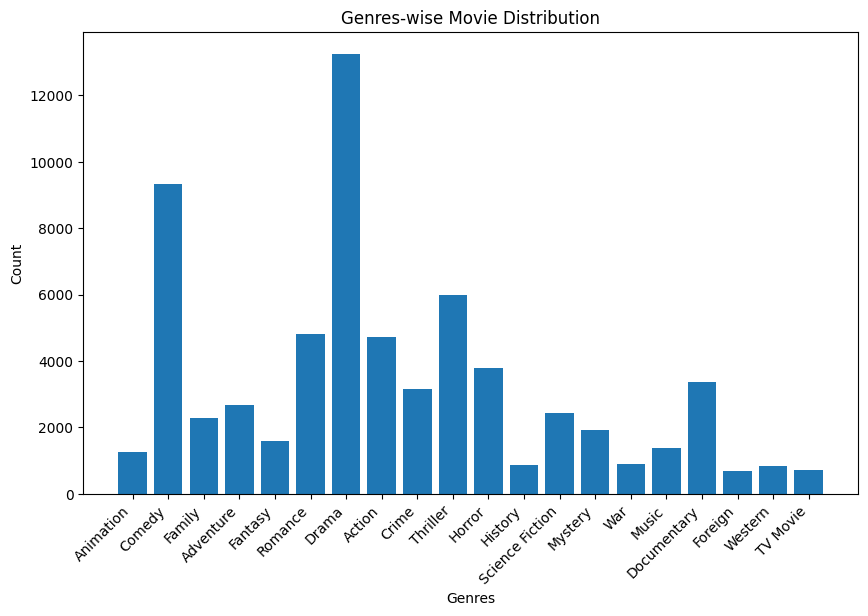

In [37]:
# Your list of genres
genres_list = category

# Use Counter to get the count of each item
genre_counts = Counter(genres_list)

plt.figure(figsize=(10, 6))
plt.bar(genre_counts.keys(), genre_counts.values())
plt.title('Genres-wise Movie Distribution')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

In [38]:
# Engligh movies
category = []
from tqdm.notebook import tqdm
for cat in tqdm(data_full['cast']):
    category = category + cat

  0%|          | 0/44500 [00:00<?, ?it/s]

In [39]:
d = dict(sorted(Counter(category).items(),key=lambda x:x[1],reverse=True)[:50])

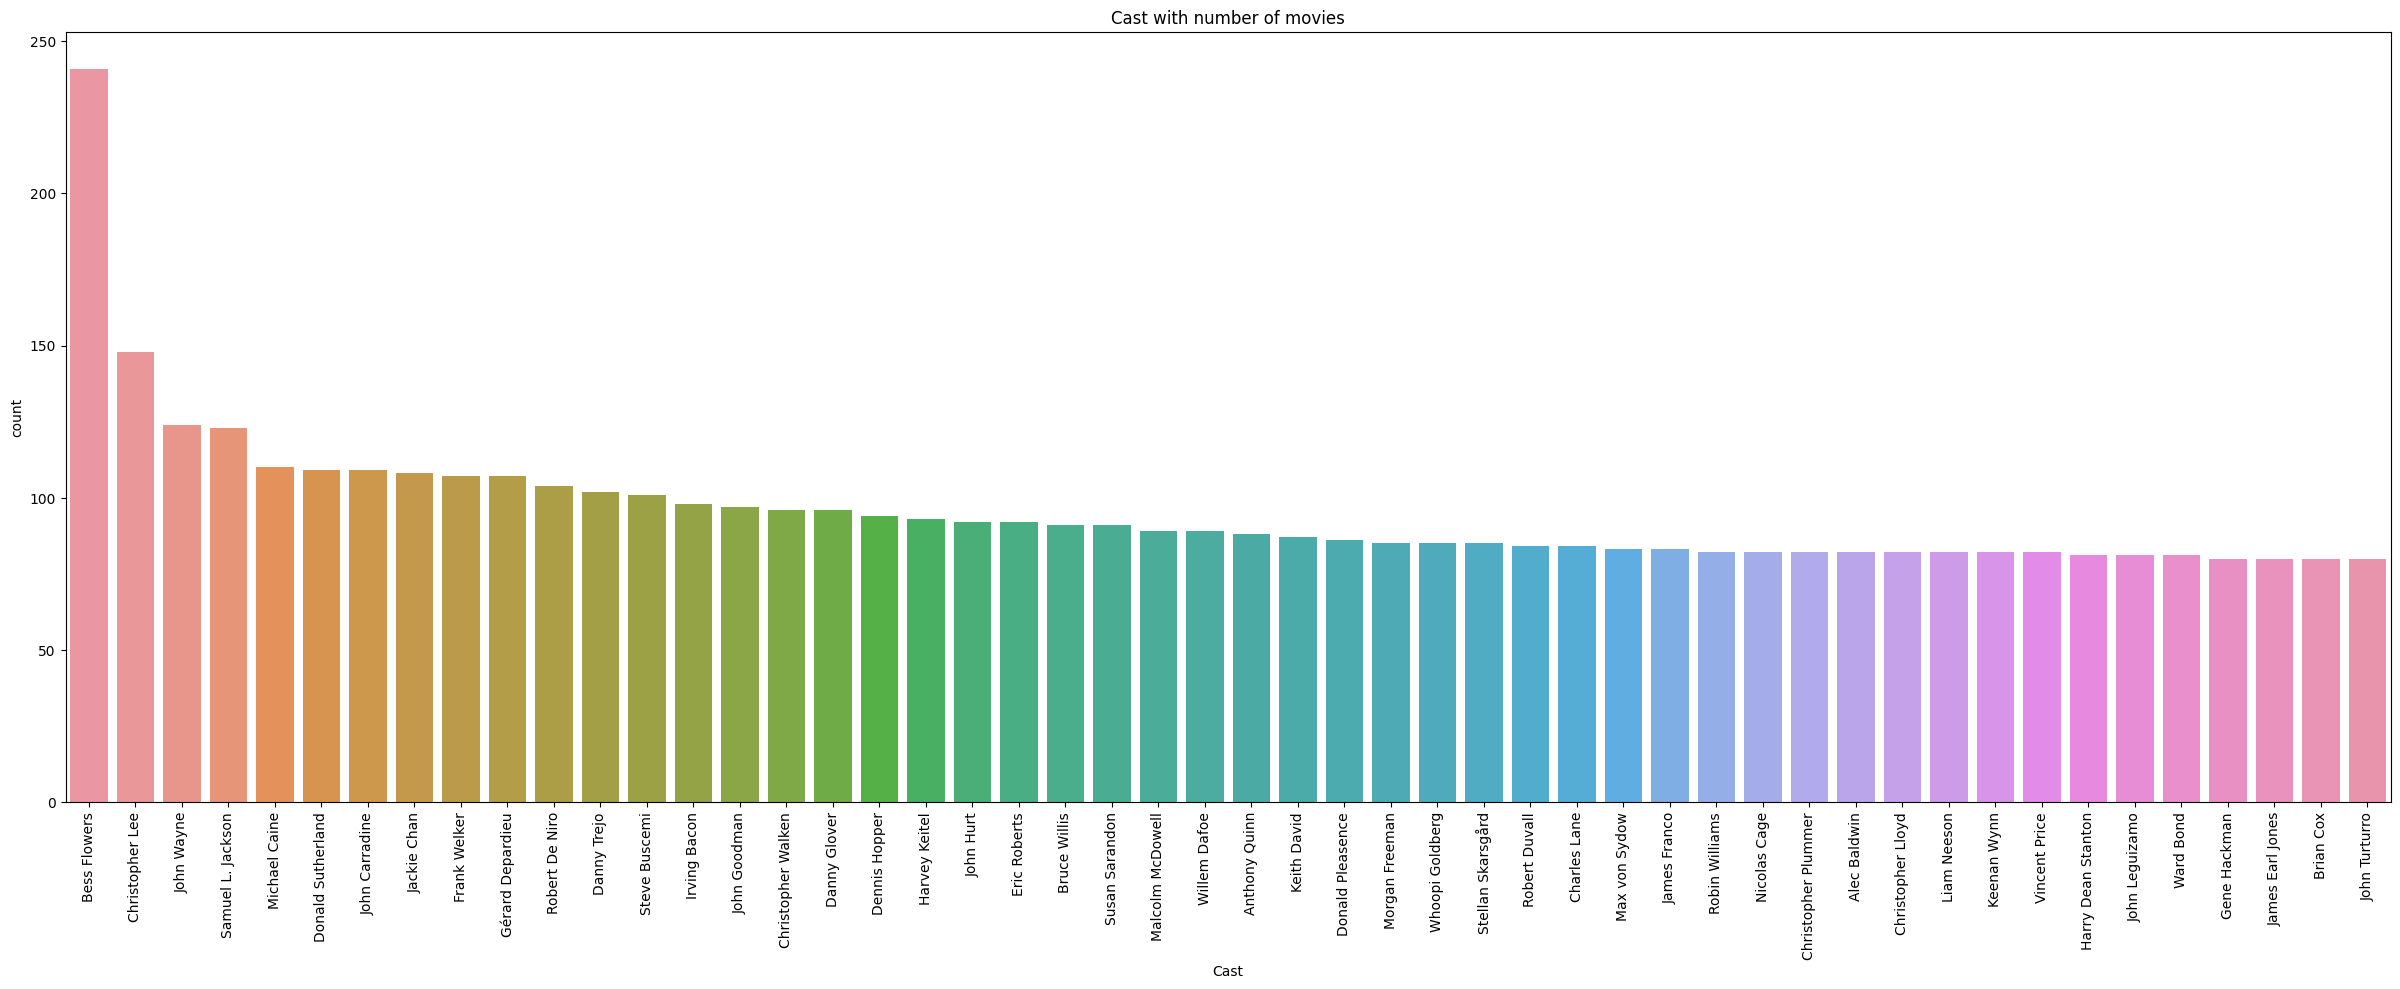

In [41]:
all_cast = []
for i in d:
    all_cast = all_cast + [i]*d[i]

plt.figure(figsize=(30,10))
plt.title('Cast with number of movies')
sns.countplot(x=all_cast,data=data_full)
plt.xticks(rotation=90)
plt.xlabel('Cast')
plt.show()

In [42]:
import string
import re
from nltk.corpus import stopwords
from nltk import word_tokenize

punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ''' + string.punctuation

def preprocess(text):


    #remove punctuations
    translator = str.maketrans('', '', punctuations)
    text = text.translate(translator)

    #remove numbers
    text = re.sub("[0123456789]", '', text)

    #remove elongation
    text = re.sub("[إأآا]", "ا", text)

    text = ' '.join(word for word in text.split() if word not in stop_words)

    return text

In [43]:
metadata['overview']

0        Led by Woody, Andy's toys live happily in his ...
1        When siblings Judy and Peter discover an encha...
2        A family wedding reignites the ancient feud be...
3        Cheated on, mistreated and stepped on, the wom...
4        Just when George Banks has recovered from his ...
                               ...                        
45532    Yet another version of the classic epic, with ...
45534    An artist struggles to finish his work while a...
45535    When one of her hits goes wrong, a professiona...
45536    In a small town live two brothers, one a minis...
45537    50 years after decriminalisation of homosexual...
Name: overview, Length: 44500, dtype: object

# Intial Recommendation

**Using Count Vectoriser**

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def make_recommendation(metadata=data_full):

    #grabbing the new wordsoup from the user
    searchTerms = get_searchTerms()

    ################# filter dataframe for recommendation #################

    if searchTerms[4]:
        metadata_copy = metadata[metadata['original_language']==searchTerms[4].lower()]
    if searchTerms[3]:
          metadata_copy = metadata[metadata['overview'].str.contains(searchTerms[3].lower())]

    if searchTerms[2]:
        metadata_copy = metadata[metadata['popularity']>=float(searchTerms[2].replace(' ', ''))]

    if searchTerms[0]:

        f_data = metadata_copy[metadata_copy['genres'].apply(lambda x: any(t.strip().title() in x for t in searchTerms[0].split(',')))]
#         f_data = metadata_copy[metadata_copy['genres'].apply(lambda x: searchTerms[0] in x)]
        if len(f_data):
            metadata_copy = f_data

    if searchTerms[1]:

        f = lambda x: any(t.strip().title() in ' '.join(x).split() for t in searchTerms[1].split(','))

        f_data = metadata_copy[metadata_copy['cast'].apply(f)]


#         f_data = metadata_copy[metadata_copy['cast'].apply(lambda x: searchTerms[1] in ' '.join(x).split())]
        if len(f_data):
            metadata_copy = f_data

    #######################################################################

    #Vectorizing the entire matrix as described above!

    count = CountVectorizer(stop_words='english')

    count_matrix = count.fit_transform(metadata_copy['soup'])

    #running pairwise cosine similarity
    cosine_sim2 = cosine_similarity(count_matrix, count_matrix) #getting a similarity matrix

    #sorting cosine similarities by highest to lowest
    sim_scores = list(enumerate(cosine_sim2[-1,:]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    #matching the simix
    # similarities to the movie titles and ids
    ranked_titles = []
    for i in range(1, 11):
        try:
            indx = sim_scores[i][0]
            ranked_titles.append([metadata_copy['title'].iloc[indx]])
        except:
            pass
    ranked_titles = pd.DataFrame(np.array(ranked_titles)[:,0],columns=['title'])
    return ranked_titles

In [45]:
#let's try our recommendation function now
print(make_recommendation())

What Movie Genre are you interested in ? [Type 'skip' to skip this question] Thriller
Who are some actors within the genre that you love ? [Type 'skip' to skip this question] Chris Evans
What are sholud be the popularity of the movie you want to watch? [Type 'skip' to skip this question] 12
What are some of the keywords that describe the movie you want to watch, like elements of the plot, whether or not it is about friendship, etc? (if multiple, please separate them with a comma)? [Type 'skip' to skip this question] new
What is the spoken language?[Type 'skip' to skip this question] en
                             title
0           No Country for Old Men
1                   Friend Request
2               Mad Max: Fury Road
3                   The Handmaiden
4                         Vampires
5                          Vertigo
6                               13
7                     Sucker Punch
8                           Dr. No
9  Return to House on Haunted Hill


**Using TF-IDF**

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
@anvil.server.callable
def make_recommendation(metadata=data_full):



# grabbing the new wordsoup from the user
    searchTerms = get_searchTerms()
    ################# filter dataframe for recommendation #################

    if searchTerms[4]:
        metadata_copy = metadata[metadata['original_language']==searchTerms[4].lower()]
    if searchTerms[3]:
          metadata_copy = metadata[metadata['overview'].str.contains(searchTerms[3].lower())]

    if searchTerms[2]:
        metadata_copy = metadata[metadata['popularity']>=float(searchTerms[2].replace(' ', ''))]

    if searchTerms[0]:

        f_data = metadata_copy[metadata_copy['genres'].apply(lambda x: any(t.strip().title() in x for t in searchTerms[0].split(',')))]
#         f_data = metadata_copy[metadata_copy['genres'].apply(lambda x: searchTerms[0] in x)]
        if len(f_data):
            metadata_copy = f_data

    if searchTerms[1]:

        f = lambda x: any(t.strip().title() in ' '.join(x).split() for t in searchTerms[1].split(','))

        f_data = metadata_copy[metadata_copy['cast'].apply(f)]


#         f_data = metadata_copy[metadata_copy['cast'].apply(lambda x: searchTerms[1] in ' '.join(x).split())]
        if len(f_data):
            metadata_copy = f_data
    #######################################################################

    # Vectorizing the entire matrix using TF-IDF

    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(metadata_copy['soup'])
    # Calculating pairwise cosine similarity

    cosine_sim2 = cosine_similarity(tfidf_matrix, tfidf_matrix)

    # Sorting cosine similarities by highest to lowest
    sim_scores = list(enumerate(cosine_sim2[-1, :]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Matching similarities to movie titles and IDs

    ranked_titles = []
    for i in range(1, 11):
        try:
            indx = sim_scores[i][0]
            ranked_titles.append([metadata_copy['title'].iloc[indx]])
        except:
            pass
    ranked_titles = pd.DataFrame(np.array(ranked_titles)[:,0],columns=['title'])
    return ranked_titles

In [48]:
#let's try our recommendation function now
print(make_recommendation())

What Movie Genre are you interested in ? [Type 'skip' to skip this question] Thriller
Who are some actors within the genre that you love ? [Type 'skip' to skip this question] Chris Evans
What are sholud be the popularity of the movie you want to watch? [Type 'skip' to skip this question] 12
What are some of the keywords that describe the movie you want to watch, like elements of the plot, whether or not it is about friendship, etc? (if multiple, please separate them with a comma)? [Type 'skip' to skip this question] new
What is the spoken language?[Type 'skip' to skip this question] en
                        title
0                          13
1                Sucker Punch
2             The Maze Runner
3               The Conjuring
4                      Powder
5                The Shortcut
6                       Locke
7  Once Upon a Time in Venice
8                    Vampires
9      No Country for Old Men


In [66]:
from flask import Flask, request, render_template
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

app = Flask(__name__)

uname = ''
question_number = 0
language = ''
actor = ''
genre = ''
year = ''

# Assuming you have loaded the 'data_full' DataFrame before this point

# Remove brackets
if data_full['cast'].dtype != object:
    data_full['cast'] = data_full['cast'].astype(str)
data_full['cast'] = data_full['cast'].str.strip('[]')

if data_full['genres'].dtype != object:
    data_full['genres'] = data_full['genres'].astype(str)
data_full['genres'] = data_full['genres'].str.strip('[]')

# remove quotes
data_full["cast"] = data_full["cast"].str.replace(r"^'|,'$", "").str.replace("'", '')
if data_full['genres'].dtype != object:
    data_full['genres'] = data_full['genres'].astype(str)
data_full["genres"] = data_full["genres"].str.replace(r"^'|,'$", "").str.replace("'", '')

# Convert 'Year' to string format
data_full['Year'] = data_full['Year'].astype(str)

data_full = data_full[~data_full.title.isin(data_full[data_full.duplicated(subset=['title'])].title.unique())].reset_index(drop=True)

data_full = pd.concat([data_full[['title', 'cast', 'Year', 'genres', 'original_language', 'popularity']]]).dropna()

data_full['cast'] = data_full['cast'].str.replace(" ", '')

# Create the new soup
data_full['soup'] = data_full['cast'] + '  ' + data_full['genres'] + '  ' + '  ' + data_full['original_language']

# Lowercasing
data_full['soup'] = data_full['soup'].apply(lambda x: ' '.join(x.lower() for x in x.split()))

# Initialize TfidfVectorizer
count = TfidfVectorizer(stop_words='english')
count_matrix1 = count.fit_transform(data_full['soup'])


def make_reco(searchTerms):
    count_matrix2 = count.transform([searchTerms])
    tf_sim2 = cosine_similarity(count_matrix1, count_matrix2)  # Assuming you want to use cosine_similarity
    print(sorted(list(enumerate(tf_sim2)), key=lambda x: x[1], reverse=True)[:10])
    idx = [i[0] for i in sorted(list(enumerate(tf_sim2)), key=lambda x: x[1], reverse=True)][:5]
    print([data_full.iloc[i]['title'] + ' (' + data_full.iloc[i]['Year'] + ') | (' + data_full.iloc[i]['genres'] + ') | ' + data_full.iloc[i]['cast'] for i in idx])
    return [data_full.iloc[i]['title'] + ' (' + data_full.iloc[i]['Year'] + ') | (' + data_full.iloc[i]['genres'] + ') | ' + data_full.iloc[i]['cast'] for i in idx]


@app.route('/')
def home():
    global uname, question_number, language, actor, genre, year
    question_number += 1

    if request.method == 'POST':
        print(request.form)
        if question_number == 1:
            if request.form['reply_val']:
                uname = ' ' + request.form['reply_val'].title()
            return render_template('index.html', td=30, ed=20, ntd=3000,
                                   data=[["I am Multilingual Movie Recommendation Bot. In what language do you want to communicate?"]],
                                   fixed=f"Hello{uname}! ")

        if question_number == 2:
            if 'en' in request.form['reply_val'].lower():
                language = 'en'
            else:
                ''
            return render_template('index.html', td=200, ed=100, ntd=2000,
                                   data=[["I am really excited!", "Are you ready?"]],
                                   fixed=f"Great choice{uname}! ")

        if question_number == 3:
            return render_template('index.html', td=200, ed=100, ntd=2000,
                                   data=[["So I can help you better!", "I need you to answer some questions plz!"]],
                                   fixed=f"First: ")

        if question_number == 4:
            return render_template('index.html', td=200, ed=100, ntd=2000,
                                   data=[["Who is your favourite actor?", "Come on, you should have at least one favourite actor."]],
                                   fixed=f"Question 1: ")

        if question_number == 5:
            if request.form['reply_val']:
                actor = ' ' + request.form['reply_val'].strip().title() + ' '
            return render_template('index.html', td=200, ed=100, ntd=2000,
                                   data=[["Which movie genre{' of' + actor if actor else ''} did you like most?"]],
                                   fixed=f"Question 2: ")

        if question_number == 6:
            if request.form['reply_val']:
                genre = request.form['reply_val'].strip()
            search_terms = language + ' ' + actor.lower().replace(' ', '') + ' ' + genre
            print('---------------')
            print(search_terms)
            print('---------------')
            return render_template('index.html', td=10, ed=5, ntd=5000, data=[make_reco(search_terms)],
                                   fixed=f"We recommend ")

    question_number = 0
    return render_template('index.html', td=30, ed=20, ntd=3000,
                           data=[["I am HipHop and my job is to recommend you movies",
                                  "Provide me your name plz?"]],
                           fixed="Hello!")


# Add a new route for the recommendation page
@app.route('/recommendation')
def recommendation():
    return render_template('recommendation.html')  # Replace 'recommendation.html' with the actual path to your recommendation HTML file


if __name__ == "__main__":
    app.run(debug=True, port=5115)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5115
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat


In [65]:
uplink_key='server_TPFEFB7TDJYYZ53WJZZXRRW5-ESK55RU5H6HPY2YX'
anvil.server.connect(uplink_key)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 862.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ws4py: filename=ws4py-0.5.1-py3-none-any.whl size=45227 sha256=fa2c614e8f87543d7ccac2cab8f2ad141e17a548c3583a4825c81a1c6ac43d4b
  Stored in directory: /root/.cache/pip/wheels/2e/7c/ad/d9c746276bf024d44296340869fcb169f1e5d80fb147351a57
Successfully built ws4py


Connecting to wss://anvil.works/uplink
Anvil websocket open
Connected to "Default Environment" as SERVER


# **End**-----------------------------------------------------------------------